In [1]:

"""
Conformer_rl Analysis Example
=============================
View the notebook in Google Colab: https://drive.google.com/drive/folders/1WAnTv4SGwEQHHqyMcbrExzUob_mOfTcM?usp=sharing
≠
This notebook gives examples of how the analysis functions in conformer_rl can be used.
The example data (example_data1.pickle, example_data2.pickle and example_data3.pickle) were all
data taken from different evaluation episodes of an actual run.

The full API reference for the analysis module can be found at: 
"""
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")
from conformer_rl import analysis

/mnt/nfs/work/yoyo-0916/miniconda3/envs/mycfmenv/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# """
# If we have multiple folders and each folder contains multiple pickled evaluation
# episodes, we can compare the average tfd_total for each folder in a single bar plot.
# """
# folders = [
#     'data/env_data/example2_27-03-2026_01:40:00opt_12_eval_5000/agent_step_70000'
# ]

# labels = [
#     'folder1'
# ]

# analysis.bar_plot_tfd_average_from_folders(folders, labels)

{'mol': <rdkit.Chem.rdchem.Mol object at 0x7fc9c82399f0>,
 'step_data': {'energy': [140.26305631408525,
                          137.53208066125342,
                          135.4975299364856,
                          137.69031002251134,
                          143.37550824322142,
                          138.10700085462287,
                          138.98020854816065,
                          141.78395549576337,
                          138.46933408031816,
                          137.83101560087852,
                          138.0321433915309,
                          144.42368305478035,
                          139.42754561120933,
                          135.50563009868026,
                          136.49867854329085,
                          142.14195284688856,
                          136.33428178417327,
                          138.35940473357957,
                          138.60485699776638,
                          137.644956536355,
                          

/mnt/nfs/work/yoyo-0916/miniconda3/envs/mycfmenv/lib/python3.9/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='folder', ylabel='tfd_total_average'>)

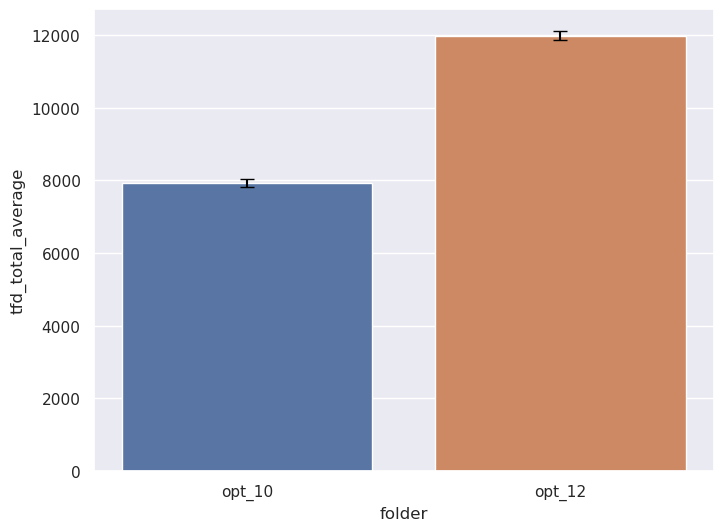

In [4]:
"""
If we have multiple folders and each folder contains multiple pickled evaluation
episodes, we can compare the average tfd_total for each folder in a single bar plot.
"""
folders = [
    'data/opt10',
    'data/opt12'
]

labels = [
    'opt_10',
    'opt_12'
]

analysis.bar_plot_tfd_average_from_folders(folders, labels)

In [ ]:
from pathlib import Path

# def find_pickle_files(root_dir):
#     root = Path(root_dir)
#     return [str(p) for p in root.rglob("*.pickle")]
# target_path = 'data/env_data/example2_23-03-2026_10:04:20opt_10'
# files = find_pickle_files(target_path)
# print(files)

In [ ]:
# analysis.load_data_from_pickle('data/env_data/example2_23-03-2026_10:04:20opt_10/agent_step_0/ep_0/data.pickle')

In [ ]:
"""
Loading the data
----------------

We load the data by specifying the filenames of the .pickle files to load. Note that we can
load multiple sets of data. In this example, each data corresponds to a different evaluation episode
taken at different points in the training of an agent. By loading all three datasets we can compare the
performance of the agent across all three episodes.

We can also specify labels for the data (which will appear in the Seaborn plots).
"""
# Specify data files to load
# files = [
#     'example_data1.pickle',
#     'example_data2.pickle',
#     'example_data3.pickle'
# ]
files = [
    # 'data/opt/data_opt_4_game_1.pickle',
    'data/opt/data_opt_6_game_1.pickle',
    'data/opt/data_opt_8_game_1.pickle',
    'data/opt/data_opt_10_game_1.pickle'
]

# Specify labels for each data set
labels = [
    # 'data_opt_4',
    'data_opt_6',
    'data_opt_8',
    'data_opt_10'
]

data = analysis.load_data_from_pickle(files, labels)

In [ ]:
# rw = analysis.load_data_from_pickle_folders('data/env_data/example2_23-03-2026_10:04:20opt_10/agent_step_0/ep_0/data.pickle')

In [ ]:
"""
bar_plot_episodic is used to compare any single scaler value across all sets of data.
In this example we visualize the total reward (sum of all rewards in the episode) across all three episodes.
"""
analysis.bar_plot_episodic("total_rewards", data)

In [ ]:
"""
histogram_episodic creates a histogram for each data set for the given key. In this case we will be creating
histogram of the energies of the conformers gneerated in each episode.
"""
analysis.histogram_episodic('energy', data, binwidth=2.5, figsize=(20, 8))

In [ ]:
"""
We can also view individual histograms or compare a subset of the episodes in an overlayed histogram using histogram_select_episodes().
"""
analysis.histogram_select_episodes(key='energy', data=data, episodes=[0], binwidth=2)

In [ ]:
"""
calculate_tfd() calculates the TFD (Torsional Fingerprint Deviation) matrix between all conformers for each dataset.
The TFD measures how similar the conformers are to each other and is helpful for determining the diversity of the conformers generated.
"""
analysis.calculate_tfd(data)

"""
We can then visualize the TFD matrices generated for each dataset.

Notice that second and third datasets have a lot of conformer pairs with low TFD. This means
that the agent generated many duplicate conformers.
"""
analysis.heatmap_episodic('tfd_matrix', data, figsize=(8, 20))

In [ ]:
analysis.cluster_heatmap_episodic('tfd_matrix', data, figsize=(8, 20))

In [ ]:
"""
We can also visualize the sum of the TFD matrices as a measure of the
diversity of the generated conformers for each dataset.
"""
analysis.bar_plot_episodic('tfd_total', data)

In [ ]:
"""
We can visualize a single molecule from one of the datasets.
"""
analysis.drawConformer(data['mol'][0], confId=5, size=(500,300))

In [ ]:
"""
We can also choose a conformer from each dataset and compare them.
"""
view = analysis.drawConformer_episodic(data, confIds=[1, 10, 15], style='stick')
view.show()

In [ ]:
"""
We can also visualize multiple generated conformers within a dataset.
"""
runIds = [0, 5, 10]
for id in runIds:
    view = analysis.drawConformer(data['mol'][0], confId=id, style='stick')
    view.show()